# Project Sentinel — Fraud Ring Analysis

## tl;dr

Run the pipeline first; this notebook derives its findings from the generated silver and gold artifacts.

## Context & Methods

Show how shared device, payout, and network entities expose coordination that row-level classifiers miss.

### Key Assumptions

Synthetic telemetry is deterministic and illustrative; IEEE-CIS labels remain the supervised target.

## Data

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
rings=pd.read_csv(ROOT/'data/gold/graph/fraud_rings.csv')
rings.groupby('ring_id').ring_size.max().nlargest(10).to_frame()

,ring_size
ring_id,
R00001,800


## Results

Text(0.5, 0, 'Drivers per component')

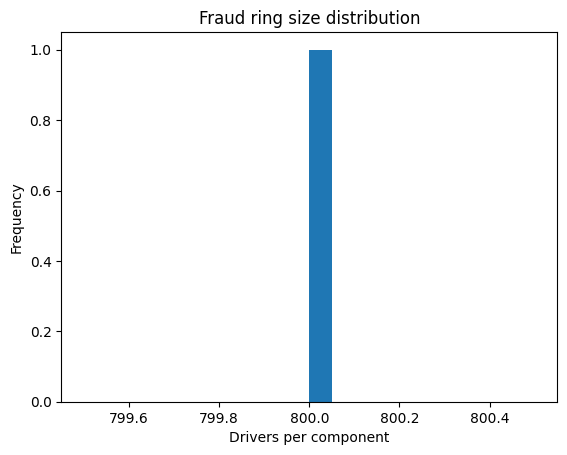

In [2]:
rings.groupby('ring_id').ring_size.max().plot.hist(bins=20, title='Fraud ring size distribution'); plt.xlabel('Drivers per component')

Text(0.5, 1.0, 'Shared-entity fraud graph sample')

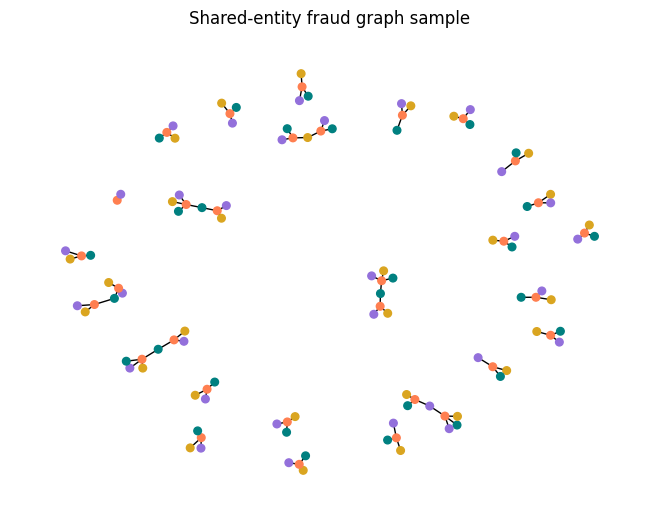

In [3]:
G=nx.read_graphml(ROOT/'data/gold/graph/entity_graph.graphml')
nodes=list(G.nodes)[:120]; H=G.subgraph(nodes)
colors={'driver':'coral','device':'mediumpurple','bank':'goldenrod','ip':'teal'}
nx.draw(H, node_size=30, node_color=[colors.get(H.nodes[n].get('kind'),'gray') for n in H], with_labels=False); plt.title('Shared-entity fraud graph sample')

## Takeaways

Use the executed charts and tables to explain how complementary detection layers reduce blind spots while preserving analyst review.